# Librerías

In [1]:
# 1. Manejo de datos y computación científica
import numpy as np

# 2. Visualización y Estética
import matplotlib.pyplot as plt

# 3. Herramientas de Machine Learning (Scikit-Learn)
from sklearn.datasets import make_classification, load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Configuración de visualización en el notebook
%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Random Forest

> **Los arboles de desicion se ajustan muy bien a los datos de entrenamiento, sin embargo no permiten generalización. El overfiting es la caracteristica mas importante. Para dar solucion, se propone el algoritmo de random foreset basado en dos caracteristicas:**
>
> **1. Se enetrenan varios árboles con diferentes subconjuntos del dataset original. Para ello se emplea bootstraping dentro de los datos del dataset inicial.**
>
> **Podemos definir como un hyperparametro el número de arboles, y también los datos que ingresan a cada árbol, para ello emplearemos la tecnica de bootstraping.**

**Fundamentos Teóricos: Bagging y Bootstrapping**

Un único árbol de decisión tiende a memorizar el ruido de los datos de entrenamiento (*overfitting*), creando fronteras de decisión extremadamente complejas y poco generalizables.

Para solucionar esto, el algoritmo **Random Forest** (Bosque Aleatorio) entrena múltiples árboles y "promedia" sus respuestas (una técnica conocida como **Agregación** o *Aggregating*). Sin embargo, si entrenamos todos los árboles con los mismos datos exactos, todos darán la misma respuesta. Para que los árboles sean distintos y aporten opiniones diversas, utilizamos **Bootstrapping**.

El *Bootstrapping* es un muestreo estadístico **con reemplazo**. Significa que, de nuestro dataset original de tamaño $m$, tomamos una muestra aleatoria, la anotamos, la devolvemos al conjunto y volvemos a tomar otra.

El resultado de este muestreo es un nuevo conjunto de tamaño $m$ donde algunos datos originales aparecerán repetidos varias veces, y otros no aparecerán en lo absoluto (los llamados datos *Out-of-Bag* o OOB).

In [2]:
# Fijamos una semilla para poder replicar el resultado exacto del documento
np.random.seed(42)

# Simulamos la técnica de muestreo con reemplazo para 10 árboles, asumiendo un dataset de 4 muestras
# Extraemos números aleatorios entre 0 y 3 (índices), creando una matriz de 10 filas (árboles) y 4 columnas (muestras extraídas)
muestreo_bootstrap = np.random.randint(0, 4, (10, 4))

print("Matriz de Bootstrapping para 10 árboles (cada fila es un árbol):")
print(muestreo_bootstrap)

Matriz de Bootstrapping para 10 árboles (cada fila es un árbol):
[[2 3 0 2]
 [2 3 0 0]
 [2 1 2 2]
 [2 2 3 0]
 [3 3 3 2]
 [1 0 1 3]
 [3 1 1 1]
 [3 3 0 0]
 [3 1 1 0]
 [3 0 0 2]]


> **Lo anterior quiere decir que el conjunto de datos del árbol 1, puede ser entrenado con las X1, X2, X3, X4 con los datos de entrenamiento 2, 1, 2, 0**
>
> **Cada fila del anterior array es usado como input para entrenar cada arbol, notese que los valores se puden repetir para entrenar el árbol i-esimo.**
>
> * **Para cada nodo de todos los arboles se selecciona un número aleatorio de características, hasta cosntruir el árbol completo.**
>
> **Al final se tendran un conjunto de arboles de desición sobre los cuales se aplicará agregación, es decir, cuando se pasa un nuevo dato de entrenamiento los arboles realizan la clasificación y se toma el valor elegido por la mayoria de los arboles**
>
> **bagging = Agregation + bootstraping**

> **Random forest permite seleccionar las caracteristicas más importantes**.
> **La estategia para optimizar los bosques pueden ser elegidos como sigue:**
> **(Fijar el numero de caracteristicas y el criterio de parada.)**
>
> **1. Determinar el error como función del número de árboles.**
>
> **2. Definido el número de árboles y calculamos el error como función del numero de caracteristicas.**
>
> **3. Con el numero de arboles fijo y el numero de caracteristicas, se optmiza el criterio de parada, (numero minimo de datos de una hoja)**

**Entrenamiento Básico (Ensambles)**

La clase `RandomForestClassifier` de Scikit-Learn abstrae por completo el proceso de Bootstrapping y Agregación (Bagging) que acabamos de estudiar. En el siguiente bloque de código probaremos el funcionamiento de este algoritmo de ensamble (ensemble learning) sobre un dataset sintético con 4 características.

Un hiperparámetro crucial es `max_depth`, el cual es un **criterio de parada**. Al limitarlo a 2, obligamos a que los árboles individuales sean "poco profundos" (modelos débiles o *weak learners*). La suma de muchos modelos débiles y poco profundos es lo que hace que el bosque final sea tan poderoso y resistente al sobreajuste.

In [3]:
# Generación de datos sintéticos controlados
X_synthetic, y_synthetic = make_classification(n_samples=1000, n_features=4,
                                               n_informative=2, n_redundant=0,
                                               random_state=0, shuffle=False)

# Instanciación y entrenamiento del Bosque Aleatorio
# max_depth=2 limita el crecimiento de los árboles individuales
clf_synthetic = RandomForestClassifier(max_depth=2, random_state=0)
clf_synthetic.fit(X_synthetic, y_synthetic)

# Predicción de una muestra arbitraria de solo ceros
prediccion_ejemplo = clf_synthetic.predict([[0, 0, 0, 0]])

print(f"Predicción del modelo para la muestra [0, 0, 0, 0]: {prediccion_ejemplo}")

Predicción del modelo para la muestra [0, 0, 0, 0]: [1]


# Parte 2: Laboratorio

> **1. Cargar load digitis**
>
> ```python
> from sklearn.datasets import load_digits
> digits = load_digits()
> print(digits.data.shape)
>
> import matplotlib.pyplot as plt
> plt.gray()
> plt.matshow(digits.images[95])
> plt.show()
> ```

**Reconocimiento de Imágenes con Bosques Aleatorios**

El dataset `load_digits` de Scikit-Learn contiene un total de 1,797 imágenes de dígitos escritos a mano (del 0 al 9). Cada una de estas imágenes es una pequeña matriz de $8 \times 8$ píxeles en escala de grises, donde cada celda almacena un valor de intensidad de color entre 0 (blanco/sin marcar) y 16 (negro/marcado máximo).

Para que un modelo de Machine Learning pueda procesarlas, la imagen tridimensional $(1797, 8, 8)$ se "aplana" (*flattening*) convirtiéndola en un vector plano de 64 características ($8 \times 8 = 64$) por cada una de las 1,797 muestras.

Cargaremos el dataset, imprimiremos sus dimensiones y visualizaremos la imagen número 95 para entender de forma visual qué es lo que intentará predecir el algoritmo.

Dimensiones del dataset aplanado (X): (1797, 64)
Dimensiones del dataset de imágenes (originales): (1797, 8, 8)
Cantidad de etiquetas a predecir (y): (1797,)


<Figure size 640x480 with 0 Axes>

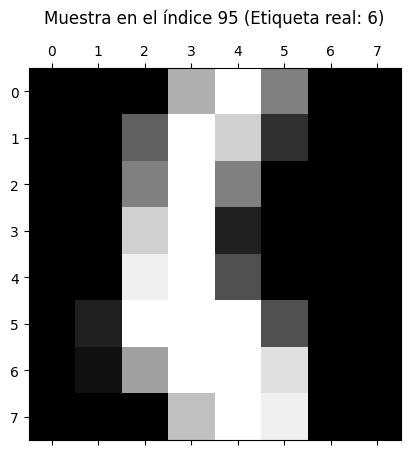

In [4]:
# Cargamos los datos de los dígitos
digits = load_digits()

print(f"Dimensiones del dataset aplanado (X): {digits.data.shape}")
print(f"Dimensiones del dataset de imágenes (originales): {digits.images.shape}")
print(f"Cantidad de etiquetas a predecir (y): {digits.target.shape}")

# Preparamos la visualización de la muestra 95
plt.gray()
plt.matshow(digits.images[95])

# Añadimos un título descriptivo extrayendo la etiqueta real
plt.title(f"Muestra en el índice 95 (Etiqueta real: {digits.target[95]})", pad=15)
plt.grid(False) # Ocultamos la cuadrícula interna del mapa de color
plt.show()

> **2. Aplicar random forest usando sklearn para clasificar el dataset**
>
> **TypeError Traceback (most recent call last)**
> `train_set, train_labels, test_set, test_labels = train_test_split(x, y, test_ratio=0.2, random_state=42)`
> `TypeError: train_test_split() got an unexpected keyword argument 'random_state'`

**Corrección del Error de Partición (`TypeError`)**

El error mostrado en la última página del documento ocurre porque se intentó definir un método manual de partición llamado `train_test_split(x, y, test_ratio)` que carece de parámetros clave como `random_state` o `test_size`, entrando en conflicto de nombres con la función oficial de Scikit-Learn.

Para solucionarlo de forma limpia y robusta, utilizaremos el `train_test_split` oficial importado de `sklearn.model_selection`. Esto asegura que los datos se mezclen de forma aleatoria controlada (usando `random_state=42` para que el resultado sea reproducible).

Entrenaremos el modelo `RandomForestClassifier` y utilizaremos **Validación Cruzada** (`cross_val_score`) con 3 pliegues (*folds*) para evaluar la estabilidad del algoritmo sobre diferentes partes del conjunto de datos de entrenamiento.

In [ ]:
# 1. División oficial de datos usando sklearn para corregir el TypeError
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target,
                                                    test_size=0.2, random_state=42)

# 2. Instanciación y entrenamiento del Bosque Aleatorio
# No limitamos la profundidad (max_depth) para que los árboles crezcan al máximo
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)

# 3. Predicción del dígito número 95 (el "6" que graficamos en la fase anterior)
some_digit = digits.data[95].reshape(1, -1)
prediction = forest_clf.predict(some_digit)
probabilities = forest_clf.predict_proba(some_digit)

print(f"Predicción del modelo para el dígito en el índice 95: {prediction[0]}")
print(f"Probabilidades asignadas a cada número (del 0 al 9):")
print(probabilities[0].round(4))

# 4. Evaluación robusta mediante Validación Cruzada (3 pliegues)
scores = cross_val_score(forest_clf, X_train, y_train, cv=3, scoring="accuracy")

print(f"\nExactitud en Validación Cruzada (3 Folds): {scores}")
print(f"Precisión promedio obtenida: {scores.mean() * 100:.2f}%")

Predicción del modelo para el dígito en el índice 95: 6
Probabilidades asignadas a cada número (del 0 al 9):
[0.   0.12 0.   0.   0.03 0.01 0.82 0.   0.01 0.01]

Exactitud en Validación Cruzada (3 Folds): [0.96242171 0.96659708 0.98121086]
Precisión promedio obtenida: 97.01%


**Ajuste Fino con Búsqueda en Cuadrícula**

El rendimiento de un Bosque Aleatorio depende de sus hiperparámetros. En lugar de probar diferentes valores manualmente, Scikit-Learn ofrece `GridSearchCV`, una herramienta que evalúa de forma exhaustiva todas las combinaciones posibles en una cuadrícula que nosotros definimos.

Analizaremos dos hiperparámetros clave:
*   `n_estimators`: El número de árboles que conformarán el bosque.
*   `max_features`: El número máximo de características que cada árbol puede evaluar al realizar una partición en un nodo.

**Nota sobre la métrica de evaluación (Scoring):**
En el fragmento original de la guía, se sugiere configurar `scoring='neg_mean_squared_error'`. El Error Cuadrático Medio (MSE) es una métrica exclusiva para problemas de **regresión** (predicción de valores numéricos continuos). Dado que este es un problema de **clasificación** de dígitos (valores discretos del 0 al 9), utilizaremos la métrica estándar `'accuracy'` para que la optimización sea matemáticamente correcta.

In [6]:
# Definición de la cuadrícula de parámetros sugerida
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]}
]

# Inicializamos el clasificador base
forest_clf_base = RandomForestClassifier(random_state=42)

# Configuramos la búsqueda usando Validación Cruzada con 5 pliegues (cv=5)
# n_jobs=-1 utiliza todos los núcleos del procesador para acelerar el cálculo
grid_search = GridSearchCV(forest_clf_base, param_grid, cv=5,
                           scoring='accuracy', return_train_score=True, n_jobs=-1)

# Ajustamos la búsqueda con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Extracción de los mejores resultados
mejores_parametros = grid_search.best_params_
mejor_precision = grid_search.best_score_

print(f"Mejor precisión obtenida durante la búsqueda: {mejor_precision * 100:.2f}%")
print("Mejores hiperparámetros encontrados:")
print(mejores_parametros)

Mejor precisión obtenida durante la búsqueda: 97.01%
Mejores hiperparámetros encontrados:
{'max_features': 8, 'n_estimators': 30}


> **# feature_importances = grid_search.best_estimator_.feature_importances_**  
> **# feature_importances**  
> **# extra_attribs = ["rooms_per_hold", "pop_per_hhold", "bedrooms_per_room"]**  
> **# cat_encoder = full_pipeline.named_transformers_["cat"]**  
> **# cat_one_hot_attribs = list(cat_encoder.categories[0])**  
> **# attributes = num_attribs + extra_attribs + cat_one_hot_attribs**  
> **# np.argsort(feature)**  
> **# sorted(zip(feature_importances, attributes), reverse=True)**

**Visualización de la Importancia de los Píxeles**

Al revisar los comentarios residuales de la página 6, se observa que pertenecen al dataset de viviendas de California del Laboratorio 7 (con variables como `rooms_per_hold` o `cat_encoder`).

Para nuestro dataset de dígitos (`load_digits`), las 64 características corresponden a la posición de cada píxel en la matriz de $8 \times 8$.

El algoritmo `RandomForestClassifier` calcula la importancia de cada píxel basándose en cuánto reduce la impureza del bosque al realizar cortes sobre él. Para interpretar este resultado de forma visual y estética, haremos lo siguiente:
1. Extraeremos las 64 importancias del mejor estimador encontrado por `GridSearchCV`.
2. Redimensionaremos este vector de 64 elementos en una matriz bidimensional de $8 \times 8$.
3. Graficaremos un mapa de calor (*heatmap*) usando el mapa de colores `hot` de matplotlib. Los píxeles más brillantes (amarillos/blancos) serán los más determinantes para el modelo, mientras que los oscuros (negros/rojos) serán los menos relevantes.

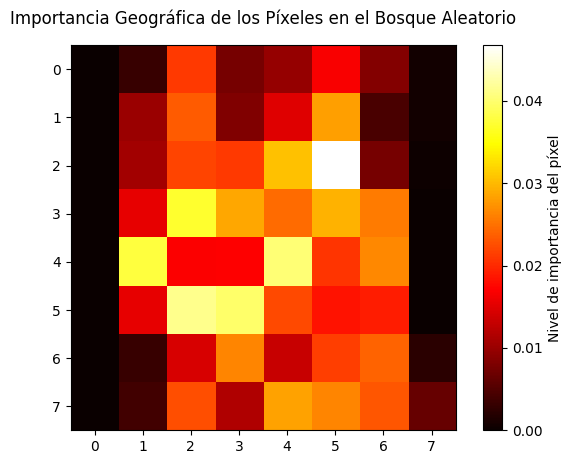

In [7]:
# 1. Extraemos el mejor modelo encontrado por GridSearchCV
best_forest = grid_search.best_estimator_

# 2. Obtenemos las importancias de las 64 características (píxeles)
importancias_pixeles = best_forest.feature_importances_

# 3. Redimensionamos el vector de 64 a una matriz de 8x8 (el tamaño original de la imagen)
importancia_imagen = importancias_pixeles.reshape(8, 8)

# 4. Graficamos el mapa de calor
plt.figure(figsize=(7, 5))
plt.imshow(importancia_imagen, cmap='hot', interpolation='nearest')

# Añadimos barra de escala de color y títulos
plt.colorbar(label='Nivel de importancia del píxel')
plt.title('Importancia Geográfica de los Píxeles en el Bosque Aleatorio', pad=15)
plt.grid(False) # Ocultamos la cuadrícula para una visualización limpia
plt.show()